In [ ]:
import yfinance as yf
import pandas as pd

assets = [
    "AAPL",
    "MSFT",
    "JNJ",
    "XOM",
    "JPM"
]

prices = yf.download(
    assets,
    start="2023-01-01",
    end="2025-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Date,,,,,
2023-01-03,122.982719,160.870605,124.292618,232.948257,94.790802
2023-01-04,124.251183,162.622009,125.451653,222.758331,95.066696
2023-01-05,122.933540,161.421295,125.423859,216.156281,97.193733
2023-01-06,127.456757,162.730347,127.823914,218.703751,98.368507
2023-01-09,127.977913,158.514252,127.295708,220.833145,96.535156


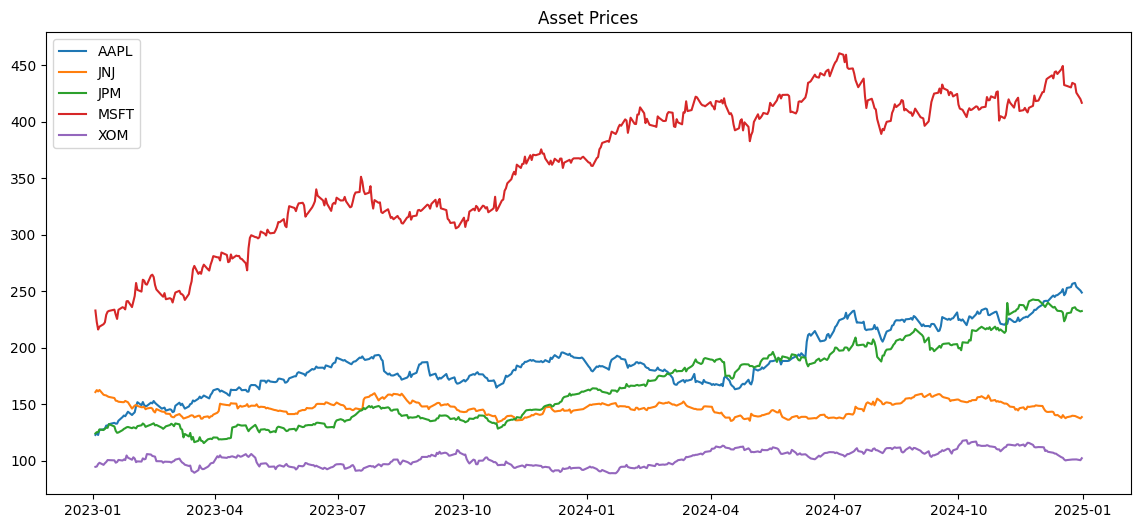

In [ ]:
plt.figure(figsize=(14,6))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Asset Prices")
plt.legend()
plt.show()

In [ ]:
returns = prices.pct_change().dropna()

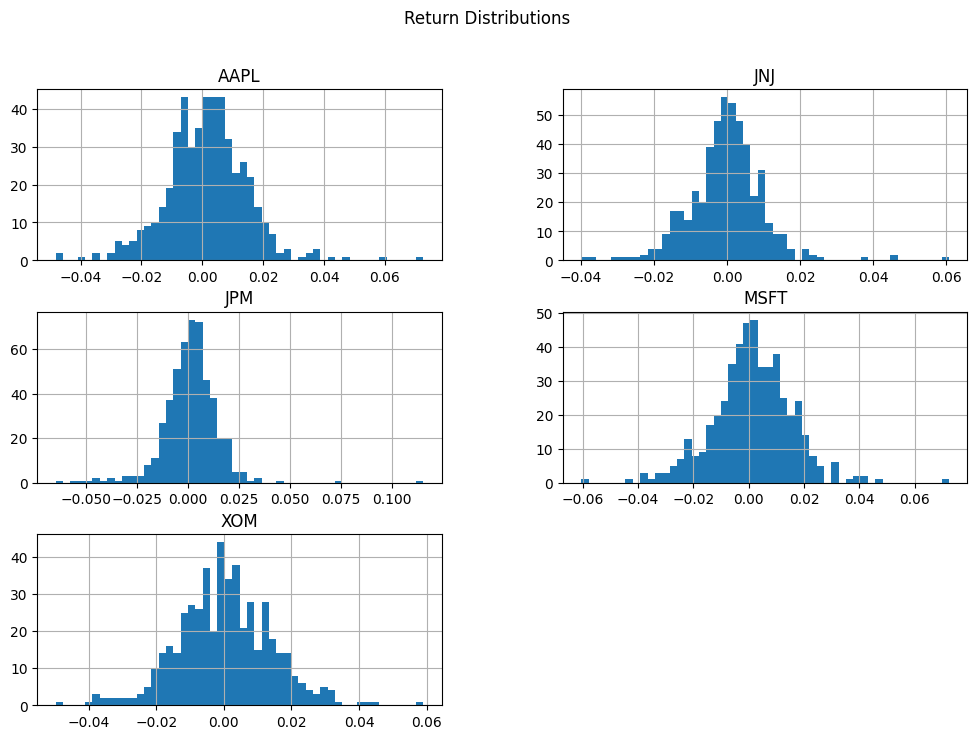

In [ ]:
returns.hist(
    figsize=(12,8),
    bins=50
)

plt.suptitle("Return Distributions")
plt.show()

In [ ]:
corr = returns.corr()

corr

Ticker,AAPL,JNJ,JPM,MSFT,XOM
Ticker,,,,,
AAPL,1.000000,0.037276,0.134590,0.505358,0.035596
JNJ,0.037276,1.000000,0.204221,-0.018811,0.152205
JPM,0.134590,0.204221,1.000000,0.118585,0.339589
MSFT,0.505358,-0.018811,0.118585,1.000000,-0.095193
XOM,0.035596,0.152205,0.339589,-0.095193,1.000000


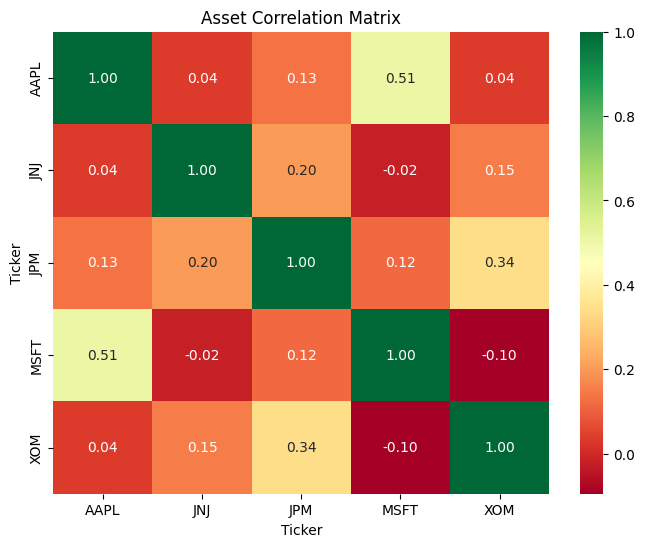

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Asset Correlation Matrix")

plt.show()

In [ ]:
equal_weights = [
    0.2,
    0.2,
    0.2,
    0.2,
    0.2
]

portfolio_equal = (
    returns * equal_weights
).sum(axis=1)

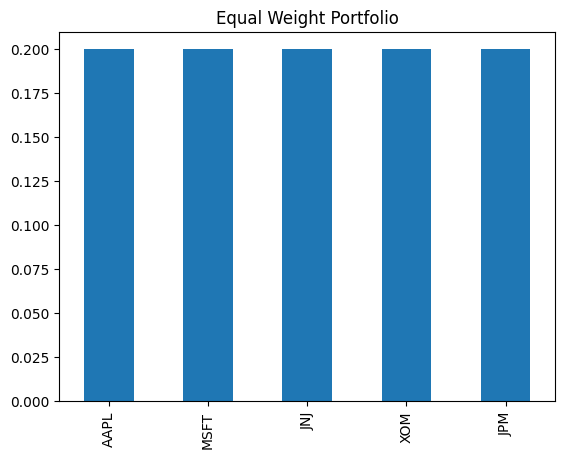

In [ ]:
weights_equal = pd.Series(
    equal_weights,
    index=assets
)

weights_equal.plot(
    kind="bar"
)

plt.title("Equal Weight Portfolio")

plt.show()

In [ ]:
custom_weights = [
    0.40,
    0.25,
    0.15,
    0.10,
    0.10
]

portfolio_weighted = (
    returns * custom_weights
).sum(axis=1)

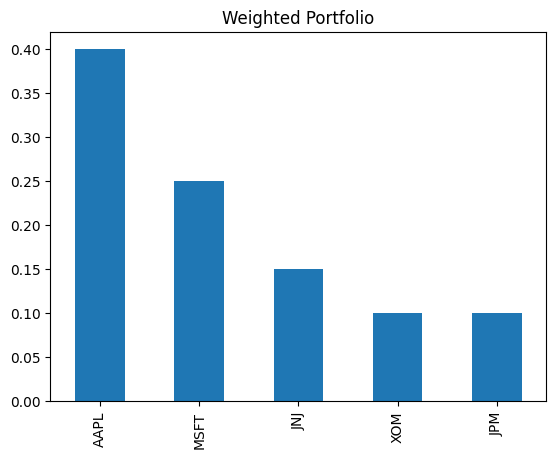

In [ ]:
weights_weighted = pd.Series(
    custom_weights,
    index=assets
)

weights_weighted.plot(
    kind="bar"
)

plt.title("Weighted Portfolio")

plt.show()

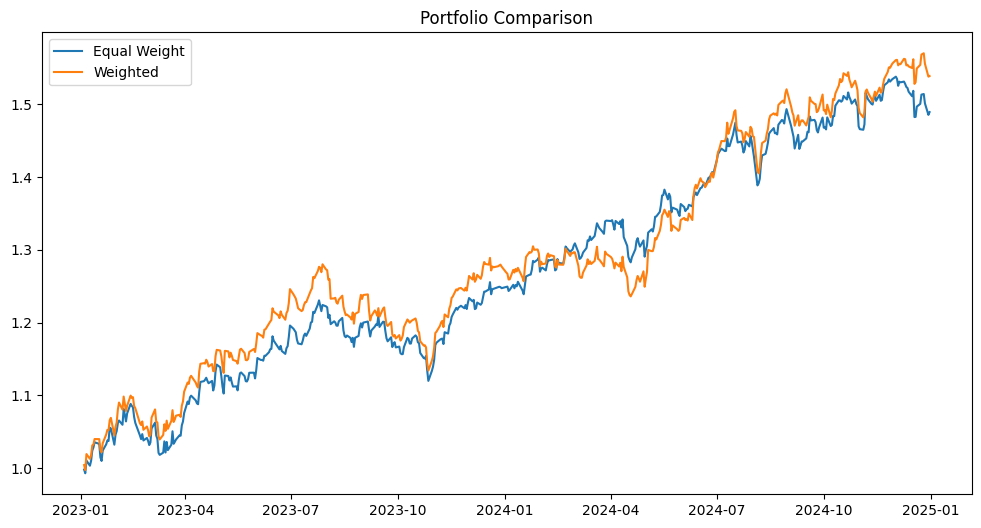

In [ ]:
import matplotlib.pyplot as plt

equal_curve = (
    1 + portfolio_equal
).cumprod()

weighted_curve = (
    1 + portfolio_weighted
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    equal_curve,
    label="Equal Weight"
)

plt.plot(
    weighted_curve,
    label="Weighted"
)

plt.legend()
plt.title("Portfolio Comparison")

plt.show()

In [ ]:
annual_return = (
    portfolio_equal.mean()
    * 252
)

In [ ]:
volatility = (
    portfolio_equal.std()
    * (252**0.5)
)

In [ ]:
sharpe = (
    annual_return
    /
    volatility
)

In [ ]:
equity_curve = (
    1 + portfolio_equal
).cumprod()

rolling_max = (
    equity_curve
    .cummax()
)

drawdown = (
    equity_curve
    /
    rolling_max
    - 1
)

max_drawdown = drawdown.min()

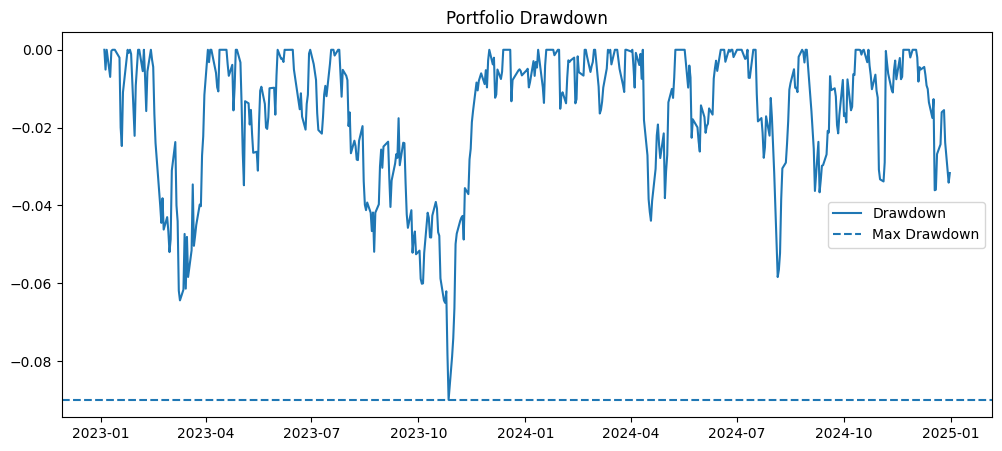

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    drawdown,
    label="Drawdown"
)

plt.axhline(
    drawdown.min(),
    linestyle="--",
    label="Max Drawdown"
)

plt.legend()
plt.title("Portfolio Drawdown")

plt.show()

In [ ]:
win_rate = (
    portfolio_equal > 0
).mean()

In [ ]:
metrics = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Volatility",
        "Sharpe",
        "Max Drawdown",
        "Win Rate"
    ],
    "Value": [
        annual_return,
        volatility,
        sharpe,
        max_drawdown,
        win_rate
    ]
})

metrics.style.format({
    "Value": "{:.2%}"
})

,Metric,Value
0,Annual Return,20.73%
1,Volatility,11.79%
2,Sharpe,175.83%
3,Max Drawdown,-8.99%
4,Win Rate,55.49%


/tmp/ipykernel_3807/1732230605.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


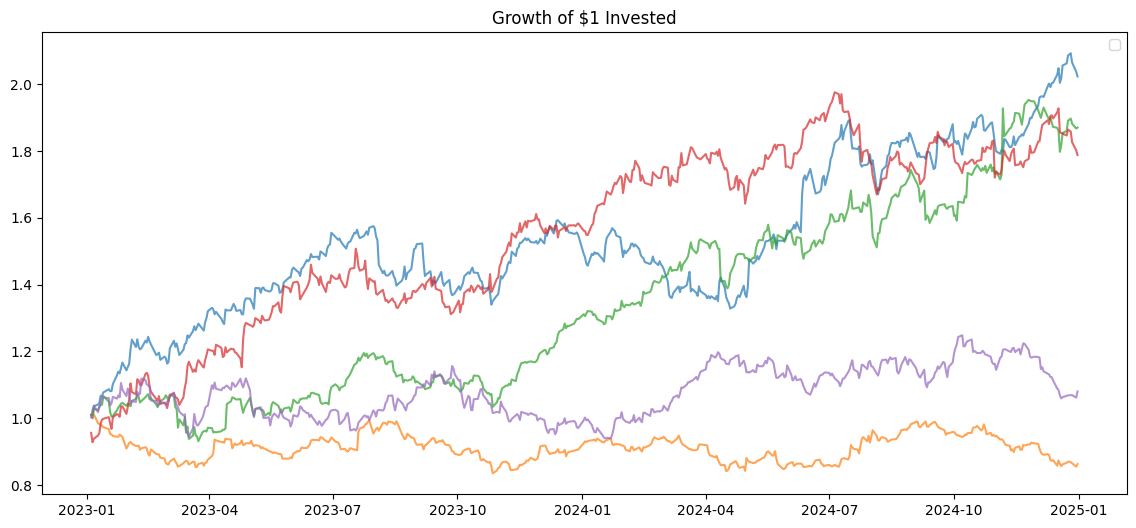

In [ ]:
asset_curves = (1 + returns).cumprod()

plt.figure(figsize=(14,6))

for col in asset_curves.columns:
    plt.plot(
        asset_curves.index,
        asset_curves[col],
        alpha=0.7
    )

plt.title("Growth of $1 Invested")

plt.legend()

plt.show()